## KNN Algorithm

In [37]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [38]:
# load the dataset
df = pd.read_csv('C:\\Users\\subham\\Desktop\\TekWorks\\KNN-Practical\\knn_regression_dataset.csv')
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [39]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [41]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


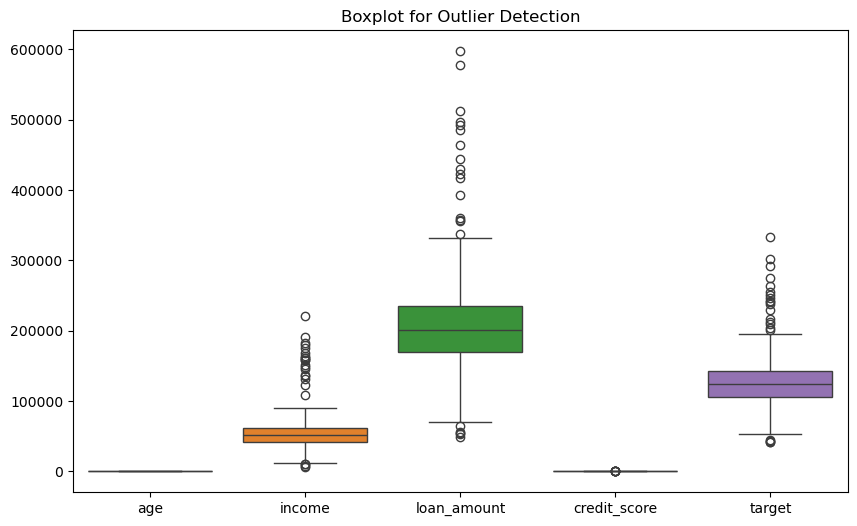

In [42]:
# Check for outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot for Outlier Detection')
plt.show()

In [43]:
# Handle missing values by filling them with median values
# find the median values of the credit score and income columns
median_credit_score = df['credit_score'].median()
median_income = df['income'].median()
median_loan_amount = df['loan_amount'].median()

# fill the missing values with the median values
df['credit_score'].fillna(median_credit_score, inplace=True)
df['income'].fillna(median_income, inplace=True)
df['loan_amount'].fillna(median_loan_amount, inplace=True)

In [44]:
# handle the outliers length of each column
Q1_credit_score = df['credit_score'].quantile(0.25)
Q3_credit_score = df['credit_score'].quantile(0.75)
IQR_credit_score = Q3_credit_score - Q1_credit_score
lower_bound_credit_score = Q1_credit_score - 1.5 * IQR_credit_score
upper_bound_credit_score = Q3_credit_score + 1.5 * IQR_credit_score

Q1_income = df['income'].quantile(0.25)
Q3_income = df['income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

Q1_loan_amount = df['loan_amount'].quantile(0.25)
Q3_loan_amount = df['loan_amount'].quantile(0.75)
IQR_loan_amount = Q3_loan_amount - Q1_loan_amount
lower_bound_loan_amount = Q1_loan_amount - 1.5 * IQR_loan_amount
upper_bound_loan_amount = Q3_loan_amount + 1.5 * IQR_loan_amount



In [45]:
# Check the size of outliers in each column
outliers_credit_score = df[(df['credit_score'] < lower_bound_credit_score) | (df['credit_score'] > upper_bound_credit_score)]
outliers_income = df[(df['income'] < lower_bound_income) | (df['income'] > upper_bound_income)]
outliers_loan_amount = df[(df['loan_amount'] < lower_bound_loan_amount) | (df['loan_amount'] > upper_bound_loan_amount)]
print(f'Number of outliers in credit score: {len(outliers_credit_score)}')
print(f'Number of outliers in income: {len(outliers_income)}')
print(f'Number of outliers in loan amount: {len(outliers_loan_amount)}')


Number of outliers in credit score: 11
Number of outliers in income: 25
Number of outliers in loan amount: 24


In [46]:
# Handle outliers by capping function

def cap_outliers(column):
    column = np.where(column > upper_bound_credit_score, upper_bound_credit_score,
                      np.where(column < lower_bound_credit_score, lower_bound_credit_score, column))
    return column

# cap the outliers in the columns
df['credit_score'] = cap_outliers(df['credit_score'])
df['income'] = cap_outliers(df['income'])
df['loan_amount'] = cap_outliers(df['loan_amount'])
